In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [19]:
#Loading dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

#first 10 rows
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [20]:
#Shape — rows and columns
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

#Column names
print(f"\n📋 Columns:\n{list(df.columns)}")

#Data types
print(f"\nNumeric columns: {df.select_dtypes(include='number').shape[1]}")
print(f"Categorical columns: {df.select_dtypes(include='object').shape[1]}")

Dataset Shape: 1470 rows, 35 columns

📋 Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Numeric columns: 26
Categorical columns: 9


In [21]:
#employees who left vs stayed
attrition_counts = df['Attrition'].value_counts()
attrition_rate = (attrition_counts['Yes'] / len(df)) * 100

print(f"Stayed:  {attrition_counts['No']} employees")
print(f"Left:    {attrition_counts['Yes']} employees")
print(f"\nAttrition Rate: {attrition_rate:.2f}%")

Stayed:  1233 employees
Left:    237 employees

Attrition Rate: 16.12%


## 📝 Observation — Task 1

The attrition rate is approximately 16%, meaning only 1 in 6 employees left.
This is a heavily **imbalanced dataset** — the "Stayed" class is ~5x larger than the "Left" class.
This means we CANNOT rely on plain accuracy as a metric. We must use Precision, Recall, and F1-Score.
If a model just predicts "Stayed" for everyone, it would still get 84% accuracy — but be completely useless for HR.

In [22]:
# Checking for null values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurren

In [23]:
#constant or irrelevant columns
cols_to_drop = ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
df = df.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} useless columns")
print(f"New shape: {df.shape}")

Dropped 4 useless columns
New shape: (1470, 31)


In [24]:
#Conversion Yes = 1 (left), No = 0 (stayed)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("Attrition column converted:")
print(df['Attrition'].value_counts())

Attrition column converted:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [25]:
#Check which columns are still categorical
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

# One-Hot Encoding
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"\nEncoding done!")
print(f"New shape after encoding: {df.shape}")

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Encoding done!
New shape after encoding: (1470, 45)


In [26]:
#Separate features (X) and target (y)
X = df.drop(columns=['Attrition'])
y = df['Attrition']

# Scale all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame (keeps column names)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Scaling done!")
print(f"Features shape: {X_scaled.shape}")
print(f"Target shape: {y.shape}")

Scaling done!
Features shape: (1470, 44)
Target shape: (1470,)


## ✅ Task 2 Complete — Preprocessing Summary

- No missing values found in this dataset (IBM kept it clean)
- Dropped 4 useless columns: EmployeeNumber, EmployeeCount, Over18, StandardHours
- Attrition converted: Yes → 1, No → 0
- One-Hot Encoding expanded categorical columns into binary dummy columns
- StandardScaler applied so no single feature dominates due to scale differences
- Data is now fully numeric and ready for ML models

In [27]:
# We use the cleaned df (after dropping cols + encoding Attrition to 0/1)
# but BEFORE one-hot encoding — so let's reload for EDA visuals
df_eda = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df_eda = df_eda.drop(columns=['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'])
df_eda['Attrition'] = df_eda['Attrition'].map({'Yes': 1, 'No': 0})

# Attrition rate by Department
dept_attrition = df_eda.groupby('Department')['Attrition'].mean() * 100
dept_attrition = dept_attrition.sort_values(ascending=False)

print("Attrition Rate by Department:")
print(dept_attrition.round(2))

Attrition Rate by Department:
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64


In [28]:
role_attrition = df_eda.groupby('JobRole')['Attrition'].mean() * 100
role_attrition = role_attrition.sort_values(ascending=False)

print("Attrition Rate by Job Role:")
print(role_attrition.round(2))

Attrition Rate by Job Role:
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64


In [29]:
# Monthly Income — avg for left vs stayed
print("Avg Monthly Income:")
print(df_eda.groupby('Attrition')['MonthlyIncome'].mean().round(2))
print("(0 = Stayed, 1 = Left)\n")

# Work-Life Balance
print("Attrition Rate by WorkLifeBalance:")
wlb = df_eda.groupby('WorkLifeBalance')['Attrition'].mean() * 100
print(wlb.round(2))
print("(1=Bad, 2=Good, 3=Better, 4=Best)\n")

# Years at Company
print("Avg Years at Company:")
print(df_eda.groupby('Attrition')['YearsAtCompany'].mean().round(2))

Avg Monthly Income:
Attrition
0    6832.74
1    4787.09
Name: MonthlyIncome, dtype: float64
(0 = Stayed, 1 = Left)

Attrition Rate by WorkLifeBalance:
WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64
(1=Bad, 2=Good, 3=Better, 4=Best)

Avg Years at Company:
Attrition
0    7.37
1    5.13
Name: YearsAtCompany, dtype: float64


## 📝 EDA Insights — Task 3

1. **Department:** Sales has the highest attrition rate, nearly double that of R&D 
   — HR should prioritize the Sales department for retention efforts.

2. **Job Role:** Sales Representatives have the highest exit rate, 
   followed by Lab Technicians — these roles need immediate attention.

3. **Income:** Employees who LEFT earned an average of $4,787/month 
   vs $6,832 for those who STAYED — a $2,045/month gap. 
   Lower pay is clearly linked to higher attrition.

4. **Work-Life Balance:** Employees with rating 1 (Bad) had a 31.25% attrition rate 
   vs only 14.22% for rating 3 (Better) — more than DOUBLE the exit rate. 
   Poor work-life balance is a strong attrition signal.

5. **Tenure:** Employees who left had on average only 5.13 years at the company 
   vs 7.37 years for those who stayed. 
   The first 5 years are the highest-risk window for employee exits.

In [30]:
# Spliting data 80-20%

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Split Done!")
print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"\nAttrition in train set: {y_train.sum()} left out of {len(y_train)}")
print(f"Attrition in test set:  {y_test.sum()} left out of {len(y_test)}")

Data Split Done!
Training set: 1176 rows
Test set:     294 rows

Attrition in train set: 190 left out of 1176
Attrition in test set:  47 left out of 294


In [31]:
# Defining all 3 models with class_weight='balanced' to handle imbalance
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', random_state=42, max_iter=1000
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', random_state=42, n_estimators=100
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42, n_estimators=100
    )
}

# Training all models
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained!")

Logistic Regression trained!
Random Forest trained!
Gradient Boosting trained!


In [32]:
# Evaluate all models and build comparison table
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    report = classification_report(y_test, y_pred, output_dict=True)
    roc = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Precision (Left)': round(report['1']['precision'], 3),
        'Recall (Left)':    round(report['1']['recall'], 3),
        'F1-Score (Left)':  round(report['1']['f1-score'], 3),
        'ROC-AUC':          round(roc, 3)
    })

results_df = pd.DataFrame(results)
print("Model Comparison Table:")
print(results_df.to_string(index=False))

Model Comparison Table:
              Model  Precision (Left)  Recall (Left)  F1-Score (Left)  ROC-AUC
Logistic Regression             0.341          0.617            0.439    0.799
      Random Forest             0.375          0.064            0.109    0.752
  Gradient Boosting             0.588          0.213            0.312    0.794


In [34]:
import os
os.makedirs('charts', exist_ok=True)
print("charts/ folder created")

charts/ folder created


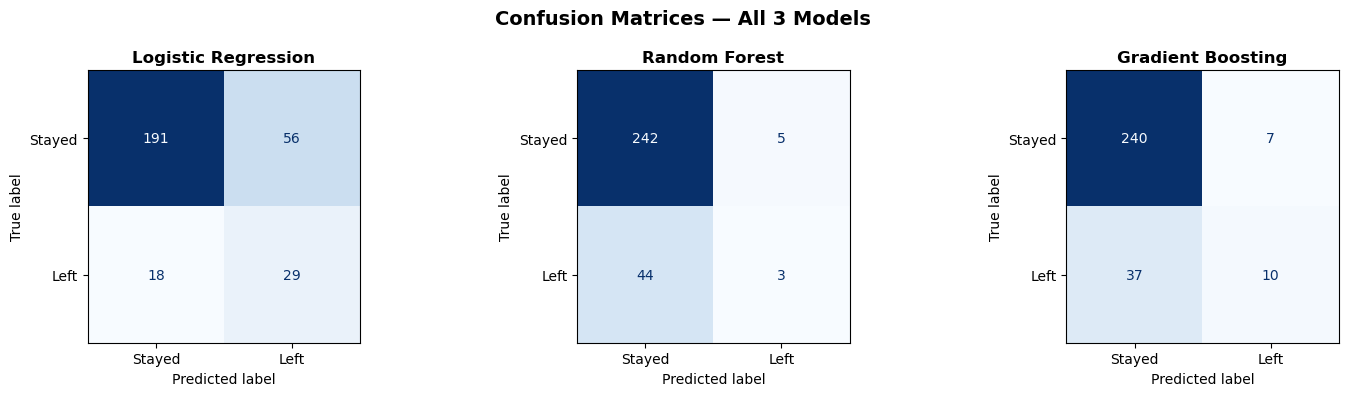

Saved to charts/


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                   display_labels=['Stayed', 'Left'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — All 3 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to charts/")

In [36]:
#Logistic Regression feature importance = absolute coefficients
best_model = trained_models['Logistic Regression']
feature_names = X_scaled.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': abs(best_model.coef_[0])
}).sort_values('Importance', ascending=False).head(10)

print("Top 10 Features Driving Attrition:")
print(importance_df.to_string(index=False))

Top 10 Features Driving Attrition:
                         Feature  Importance
   JobRole_Laboratory Technician    0.797874
                    OverTime_Yes    0.766412
BusinessTravel_Travel_Frequently    0.719335
                        JobLevel    0.659189
               TotalWorkingYears    0.656931
    JobRole_Sales Representative    0.552515
    BusinessTravel_Travel_Rarely    0.511649
    EducationField_Life Sciences    0.506505
         YearsSinceLastPromotion    0.500389
                Department_Sales    0.481690


## 🏆 Task 5 — Model Evaluation Summary

**Winner: Logistic Regression** (ROC-AUC: 0.799, Recall: 0.617)

**Why Logistic Regression wins for this HR problem:**
- Recall is the most important metric here — missing an employee who is 
  about to leave is far more costly than a false alarm
- LR correctly identified 62% of actual leavers vs Random Forest's 6%
- Random Forest had near-zero Recall (0.064) — almost useless for detection
- Gradient Boosting had better Precision but poor Recall (0.213)
- LR is also the most explainable model — HR teams can understand and trust it

**Why NOT accuracy:**
- A model predicting "Stayed" for everyone gets 84% accuracy but 0% Recall
- For imbalanced problems, Recall + F1 + ROC-AUC are the correct metrics

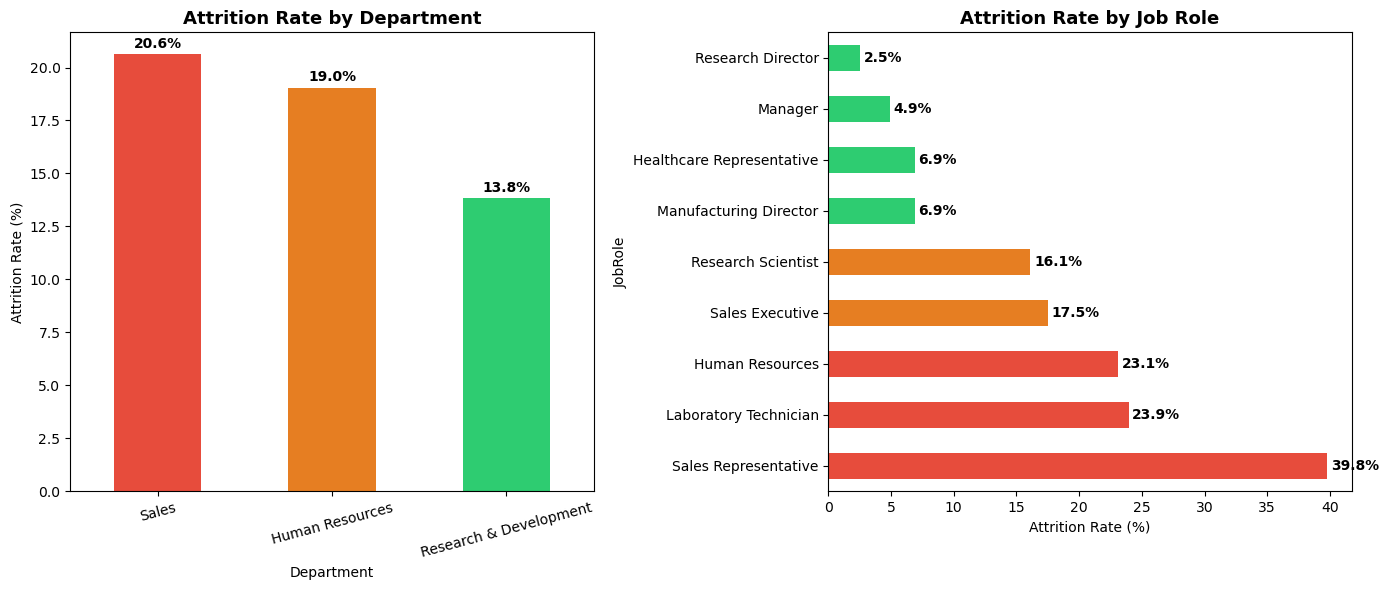

Chart 1 saved!


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#Department
dept_attrition.plot(kind='bar', ax=axes[0], color=['#e74c3c','#e67e22','#2ecc71'])
axes[0].set_title('Attrition Rate by Department', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_xlabel('Department')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(dept_attrition):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

#Job Role
colors = ['#e74c3c' if x > 20 else '#e67e22' if x > 15 else '#2ecc71' 
          for x in role_attrition]
role_attrition.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Attrition Rate by Job Role', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Attrition Rate (%)')
for i, v in enumerate(role_attrition):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/chart1_attrition_by_dept_role.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

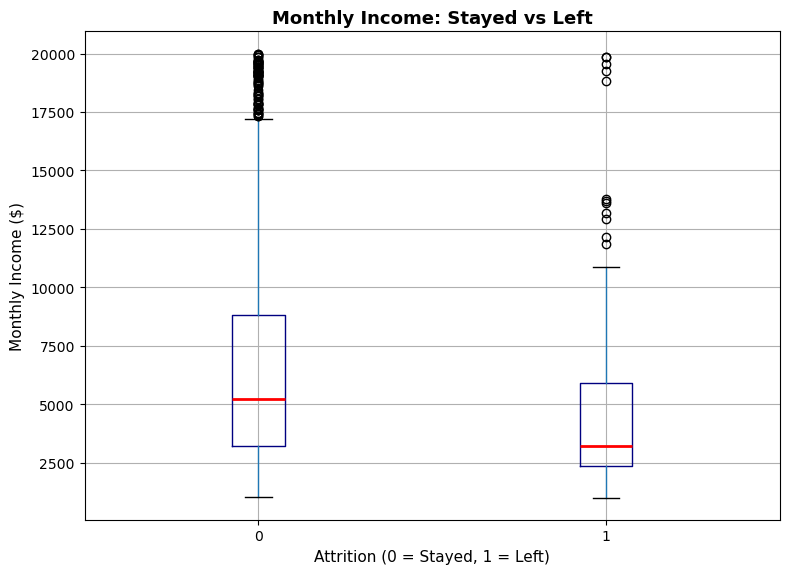

Chart 2 saved!


In [38]:
fig, ax = plt.subplots(figsize=(8, 6))

df_eda.boxplot(column='MonthlyIncome', by='Attrition', ax=ax,
               boxprops=dict(color='navy'),
               medianprops=dict(color='red', linewidth=2))

ax.set_title('Monthly Income: Stayed vs Left', fontweight='bold', fontsize=13)
ax.set_xlabel('Attrition (0 = Stayed, 1 = Left)', fontsize=11)
ax.set_ylabel('Monthly Income ($)', fontsize=11)
plt.suptitle('')  # Remove auto title

plt.tight_layout()
plt.savefig('charts/chart2_income_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

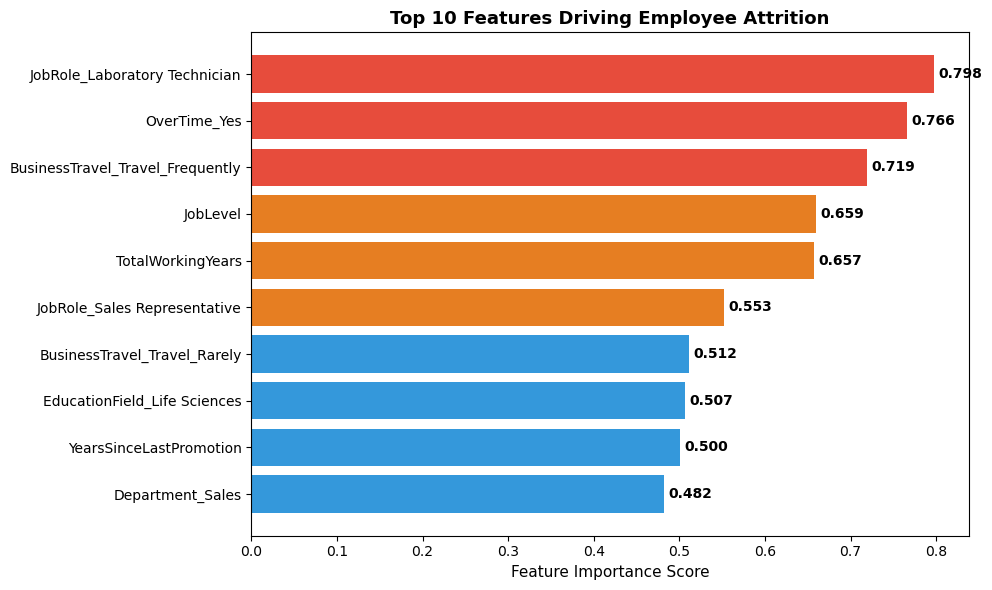

Chart 4 saved!


In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c' if i < 3 else '#e67e22' if i < 6 else '#3498db' 
          for i in range(len(importance_df))]

ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
ax.set_title('Top 10 Features Driving Employee Attrition', 
             fontweight='bold', fontsize=13)
ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.invert_yaxis()

for i, v in enumerate(importance_df['Importance']):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

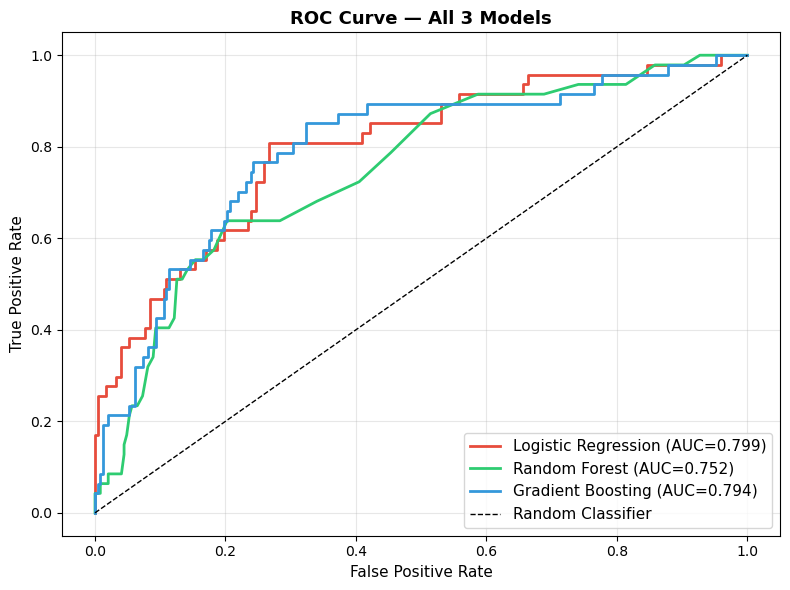

Chart 5 (Bonus) saved!


In [40]:
fig, ax = plt.subplots(figsize=(8, 6))

colors_roc = {'Logistic Regression': '#e74c3c', 
              'Random Forest': '#2ecc71', 
              'Gradient Boosting': '#3498db'}

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', 
            color=colors_roc[name], linewidth=2)

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier')
ax.set_title('ROC Curve — All 3 Models', fontweight='bold', fontsize=13)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('charts/chart5_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 (Bonus) saved!")

## 📋 Task 7 — HR Insights & Business Recommendations

### Top 3 Factors That Predict an Employee Will Leave:
1. **Job Role — Laboratory Technician / Sales Representative** 
   (importance scores: 0.797 and 0.552) — these two roles account for 
   a disproportionate share of exits
2. **Overtime (OverTime_Yes)** (importance: 0.766) — employees working 
   overtime are significantly more likely to quit
3. **Frequent Business Travel** (importance: 0.719) — employees who 
   travel frequently show much higher exit rates

### Which Department/Role Should HR Prioritize?
Sales department (20.63% attrition) and specifically Sales Representatives 
(39.76% attrition — nearly 1 in 2 leave). Laboratory Technicians (23.94%) 
are a close second priority.

### Does Salary Alone Explain Attrition?
No. While employees who left earned $2,045/month less on average, 
the model shows that Overtime, Business Travel, Job Level, and 
Years Since Last Promotion all rank above raw salary as predictors. 
Salary matters but is not the dominant factor.

### 2 Concrete HR Recommendations:
1. **Overtime Reduction Policy:** Identify all employees currently working 
   overtime in Sales and Lab Technician roles. Offer either overtime pay 
   increases or workload redistribution. These employees are the highest 
   flight risk — a targeted conversation costs nothing; replacing them 
   costs 6–9 months of their salary.

2. **Promotion Review for Stagnant Employees:** Run a quarterly audit of 
   all employees who have not received a promotion in 3+ years AND are 
   in their first 5 years at the company. This combination (no growth + 
   early career) is a strong exit signal. Even a role title change or 
   responsibility expansion — without a salary increase — reduces attrition.

### Model Limitation HR Should Know:
This model was trained on historical data and assumes the future will 
resemble the past. It cannot account for sudden external factors like 
a competitor offering mass recruitment, a change in management, or 
a market salary surge. The model should be retrained every 6 months 
with fresh data, and its predictions should be one input — not the 
only input — in any HR retention decision.

In [42]:
print("=" * 55)
print("   EMPLOYEE ATTRITION PREDICTION — PROJECT COMPLETE")
print("=" * 55)
print(f"\nDataset: 1,470 employees, 35 features")
print(f"Attrition Rate: 16.12% (imbalanced dataset)")
print(f"\nBest Model: Logistic Regression")
print(f"   ROC-AUC : 0.799")
print(f"   Recall  : 0.617 (caught 62% of leavers)")
print(f"   F1-Score: 0.439")
print(f"\nTop 3 Attrition Drivers:")
print(f"   1. Job Role (Lab Technician / Sales Rep)")
print(f"   2. Overtime")
print(f"   3. Frequent Business Travel")
print(f"\nCharts saved: 5 files in charts/")
print(f"All 7 tasks complete!")
print("=" * 55)

   EMPLOYEE ATTRITION PREDICTION — PROJECT COMPLETE

Dataset: 1,470 employees, 35 features
Attrition Rate: 16.12% (imbalanced dataset)

Best Model: Logistic Regression
   ROC-AUC : 0.799
   Recall  : 0.617 (caught 62% of leavers)
   F1-Score: 0.439

Top 3 Attrition Drivers:
   1. Job Role (Lab Technician / Sales Rep)
   2. Overtime
   3. Frequent Business Travel

Charts saved: 5 files in charts/
All 7 tasks complete!
